# Support Vector Machines (SVM) for Classification
## A Comprehensive Guide with Scikit-Learn

**Target Audience:** Data Science Students  
**Dataset:** Breast Cancer (Binary Classification)  
**Topics Covered:** SVM fundamentals, kernel tricks, hyperparameter tuning, cross-validation

---

## Learning Objectives

By the end of this notebook, you will understand:
1. The fundamental concepts of Support Vector Machines for classification
2. How kernel tricks enable SVM to handle non-linear data
3. The role of key hyperparameters (C and gamma) in model performance
4. How to use cross-validation for robust model evaluation
5. Best practices for training and evaluating SVM classifiers


## Section 1: Introduction to Support Vector Machines

### What is SVM?

Support Vector Machines (SVM) is a powerful supervised learning algorithm used for classification and regression tasks. The core idea is elegant: **find the hyperplane that maximizes the margin between different classes while minimizing classification errors.**

### Key Concepts

- **Hyperplane**: A decision boundary that separates classes. In 2D, it's a line; in 3D, it's a plane; in higher dimensions, it's a hyperplane.
- **Margin**: The distance between the hyperplane and the nearest data points (support vectors). SVM maximizes this margin.
- **Support Vectors**: The data points that lie closest to the decision boundary. These points are critical for defining the hyperplane.
- **Kernel Trick**: A mathematical technique that allows SVM to handle non-linear data by implicitly mapping it to a higher-dimensional space.

### Why Use SVM?

✓ Effective in high-dimensional spaces  
✓ Memory efficient (uses only support vectors)  
✓ Versatile (linear and non-linear classification)  
✓ Well-suited for binary and multi-class problems  

### When to Use SVM?

- Binary or multi-class classification problems
- High-dimensional datasets
- When you have a clear margin of separation
- When interpretability is less critical than accuracy


## Section 2: Dataset Exploration and Preparation

We'll use the Breast Cancer dataset from scikit-learn. This is a real-world binary classification problem where we predict whether a tumor is malignant or benign based on 30 features.

In [1]:
# Import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the Breast Cancer dataset
cancer_data = load_breast_cancer()
X = cancer_data.data
y = cancer_data.target
feature_names = cancer_data.feature_names
target_names = cancer_data.target_names

# Create a DataFrame for easier exploration
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['target_name'] = df['target'].map({0: target_names[0], 1: target_names[1]})

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())

Dataset Shape: (569, 32)

First few rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst perimeter  w

Target Variable Distribution:
target_name
benign       357
malignant    212
Name: count, dtype: int64

Class Proportions:
target_name
benign       0.627417
malignant    0.372583
Name: proportion, dtype: float64


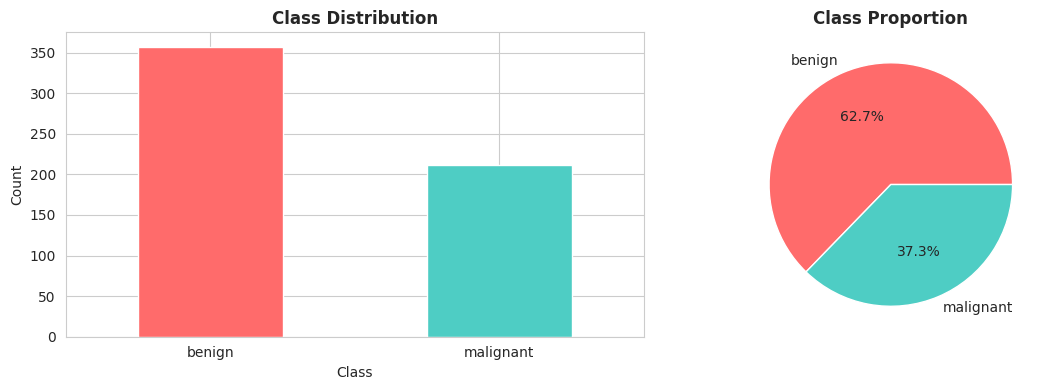


✓ Dataset is relatively balanced (good for SVM)


In [3]:
# Explore the target variable
print("Target Variable Distribution:")
print(df['target_name'].value_counts())
print("\nClass Proportions:")
print(df['target_name'].value_counts(normalize=True))

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
df['target_name'].value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Class')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Pie chart
df['target_name'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                        colors=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('Class Proportion', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n✓ Dataset is relatively balanced (good for SVM)")

In [4]:
# Feature statistics
print("Feature Statistics:")
print(df.iloc[:, :-2].describe().round(2))

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\n✓ No missing values found")

Feature Statistics:
       mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
count       569.00        569.00          569.00     569.00           569.00   
mean         14.13         19.29           91.97     654.89             0.10   
std           3.52          4.30           24.30     351.91             0.01   
min           6.98          9.71           43.79     143.50             0.05   
25%          11.70         16.17           75.17     420.30             0.09   
50%          13.37         18.84           86.24     551.10             0.10   
75%          15.78         21.80          104.10     782.70             0.11   
max          28.11         39.28          188.50    2501.00             0.16   

       mean compactness  mean concavity  mean concave points  mean symmetry  \
count            569.00          569.00               569.00         569.00   
mean               0.10            0.09                 0.05           0.18   
std                0.0

In [5]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nTest set class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training set size: 455
Test set size: 114

Training set class distribution:
0    170
1    285
Name: count, dtype: int64

Test set class distribution:
0    42
1    72
Name: count, dtype: int64


In [6]:
# Feature Scaling - CRITICAL for SVM!
# SVM is sensitive to feature scaling because it uses distance-based calculations

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Applied (StandardScaler)")
print("\nBefore Scaling - First 5 features (first 3 samples):")
print(X_train[:3, :5])
print("\nAfter Scaling - First 5 features (first 3 samples):")
print(X_train_scaled[:3, :5])
print("\n✓ Features now have mean ≈ 0 and std ≈ 1")

Feature Scaling Applied (StandardScaler)

Before Scaling - First 5 features (first 3 samples):
[[1.032e+01 1.635e+01 6.531e+01 3.249e+02 9.434e-02]
 [2.018e+01 1.954e+01 1.338e+02 1.250e+03 1.133e-01]
 [1.066e+01 1.515e+01 6.749e+01 3.496e+02 8.792e-02]]

After Scaling - First 5 features (first 3 samples):
[[-1.07200079 -0.6584246  -1.0880801  -0.93927364 -0.13593988]
 [ 1.74874285  0.06650173  1.75115682  1.74555856  1.27446827]
 [-0.97473376 -0.93112416 -0.99770871 -0.86758911 -0.61351479]]

✓ Features now have mean ≈ 0 and std ≈ 1


## Section 3: Linear SVM Classification

Let's start with a simple linear SVM classifier. This is the foundation for understanding more complex kernels.

In [7]:
# Train a Linear SVM
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

# Make predictions
y_pred_linear = svm_linear.predict(X_test_scaled)

print("Linear SVM Model Trained!")
print(f"Number of support vectors: {len(svm_linear.support_vectors_)}")
print(f"Support vectors as % of training data: {len(svm_linear.support_vectors_) / len(X_train_scaled) * 100:.2f}%")

Linear SVM Model Trained!
Number of support vectors: 32
Support vectors as % of training data: 7.03%


In [8]:
# Evaluation Metrics
def evaluate_model(y_true, y_pred, model_name):
    """Calculate and display evaluation metrics"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"\n{'='*50}")
    print(f"{model_name} - Evaluation Metrics")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

metrics_linear = evaluate_model(y_test, y_pred_linear, "Linear SVM")


Linear SVM - Evaluation Metrics
Accuracy:  0.9737
Precision: 0.9859
Recall:    0.9722
F1-Score:  0.9790


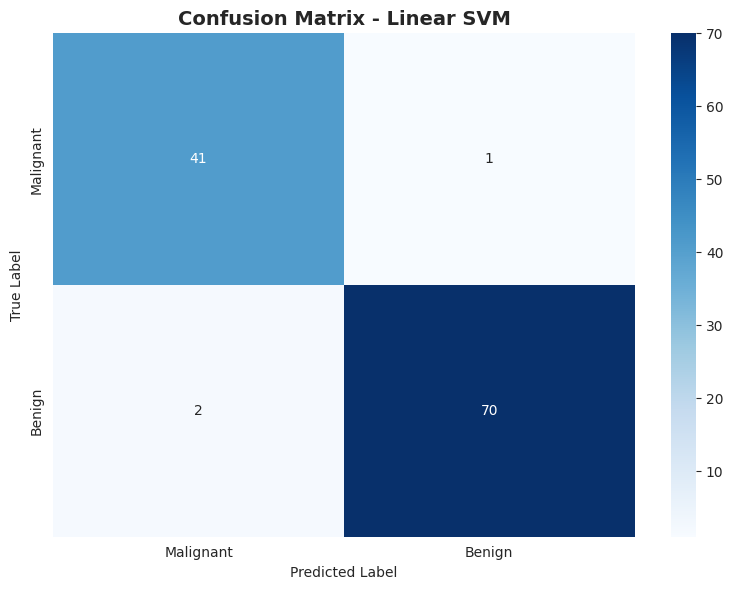


Confusion Matrix Interpretation:
True Negatives (TN):  41 - Correctly predicted Malignant
False Positives (FP): 1 - Incorrectly predicted Benign (Type I Error)
False Negatives (FN): 2 - Incorrectly predicted Malignant (Type II Error)
True Positives (TP):  70 - Correctly predicted Benign


In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_linear)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix - Linear SVM', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (TN):  {cm[0, 0]} - Correctly predicted Malignant")
print(f"False Positives (FP): {cm[0, 1]} - Incorrectly predicted Benign (Type I Error)")
print(f"False Negatives (FN): {cm[1, 0]} - Incorrectly predicted Malignant (Type II Error)")
print(f"True Positives (TP):  {cm[1, 1]} - Correctly predicted Benign")

In [10]:
# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_linear, 
                          target_names=['Malignant', 'Benign']))


Detailed Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.98      0.96        42
      Benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Section 4: Kernel Tricks Explained

### What is the Kernel Trick?

The kernel trick is a mathematical technique that allows SVM to efficiently handle non-linear data without explicitly computing the transformation to a higher-dimensional space. Instead of mapping data to a high-dimensional space (which is computationally expensive), kernels compute the dot product in that space directly.

### Common Kernels

1. **Linear Kernel**: `K(x, y) = x · y`
   - Use when data is linearly separable
   - Computationally efficient
   - Interpretable

2. **RBF (Radial Basis Function) Kernel**: `K(x, y) = exp(-γ||x - y||²)`
   - Use for non-linear data
   - Most versatile and commonly used
   - Controlled by gamma parameter

3. **Polynomial Kernel**: `K(x, y) = (γ(x · y) + r)^d`
   - Use for polynomial decision boundaries
   - Controlled by degree and gamma

4. **Sigmoid Kernel**: `K(x, y) = tanh(γ(x · y) + r)`
   - Similar to neural networks
   - Less commonly used


In [11]:
# Train SVM with different kernels
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
svm_models = {}
predictions = {}
metrics_dict = {}

print("Training SVM with different kernels...\n")

for kernel in kernels:
    # Train model
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train_scaled, y_train)
    svm_models[kernel] = svm
    
    # Make predictions
    y_pred = svm.predict(X_test_scaled)
    predictions[kernel] = y_pred
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    n_support = len(svm.support_vectors_)
    
    metrics_dict[kernel] = {'accuracy': accuracy, 'f1': f1, 'support_vectors': n_support}
    
    print(f"{kernel.upper():10} - Accuracy: {accuracy:.4f} | F1-Score: {f1:.4f} | Support Vectors: {n_support}")

Training SVM with different kernels...

LINEAR     - Accuracy: 0.9737 | F1-Score: 0.9790 | Support Vectors: 32
RBF        - Accuracy: 0.9825 | F1-Score: 0.9861 | Support Vectors: 97
POLY       - Accuracy: 0.9123 | F1-Score: 0.9351 | Support Vectors: 145
SIGMOID    - Accuracy: 0.9298 | F1-Score: 0.9437 | Support Vectors: 66


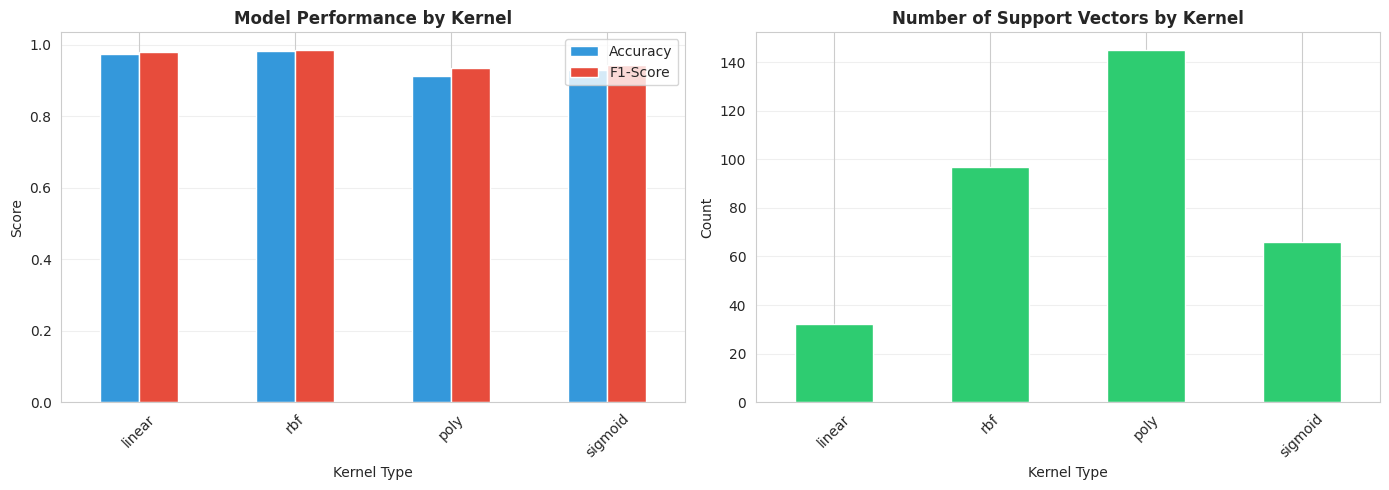


Kernel Comparison Summary:
         accuracy      f1  support_vectors
linear     0.9737  0.9790             32.0
rbf        0.9825  0.9861             97.0
poly       0.9123  0.9351            145.0
sigmoid    0.9298  0.9437             66.0


In [12]:
# Compare kernels visually
metrics_df = pd.DataFrame(metrics_dict).T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy and F1-Score comparison
metrics_df[['accuracy', 'f1']].plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Model Performance by Kernel', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Kernel Type')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].legend(['Accuracy', 'F1-Score'])
axes[0].grid(axis='y', alpha=0.3)

# Support vectors comparison
metrics_df['support_vectors'].plot(kind='bar', ax=axes[1], color='#2ecc71')
axes[1].set_title('Number of Support Vectors by Kernel', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Kernel Type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKernel Comparison Summary:")
print(metrics_df.round(4))

## Section 5: Hyperparameter Tuning

### Key Hyperparameters for SVM

**C (Regularization Parameter)**
- Controls the trade-off between maximizing margin and minimizing classification errors
- Small C: Larger margin, more errors (underfitting)
- Large C: Smaller margin, fewer errors (overfitting)
- Default: 1.0

**Gamma (Kernel Coefficient)**
- Only relevant for RBF, polynomial, and sigmoid kernels
- Defines how far the influence of a single training example reaches
- Small gamma: Far-reaching influence (smoother decision boundary)
- Large gamma: Close influence (more complex decision boundary)
- Default: 1 / (n_features * X.var())


In [13]:
# Demonstrate the effect of C parameter
C_values = [0.1, 1, 10, 100]
train_scores_C = []
test_scores_C = []

print("Effect of C Parameter (Linear Kernel):")
print(f"{'C Value':<10} {'Train Accuracy':<20} {'Test Accuracy':<20}")
print("-" * 50)

for C in C_values:
    svm = SVC(kernel='linear', C=C, random_state=42)
    svm.fit(X_train_scaled, y_train)
    
    train_score = svm.score(X_train_scaled, y_train)
    test_score = svm.score(X_test_scaled, y_test)
    
    train_scores_C.append(train_score)
    test_scores_C.append(test_score)
    
    print(f"{C:<10} {train_score:<20.4f} {test_score:<20.4f}")

Effect of C Parameter (Linear Kernel):
C Value    Train Accuracy       Test Accuracy       
--------------------------------------------------
0.1        0.9846               0.9825              
1          0.9912               0.9737              
10         0.9912               0.9825              
100        0.9956               0.9737              


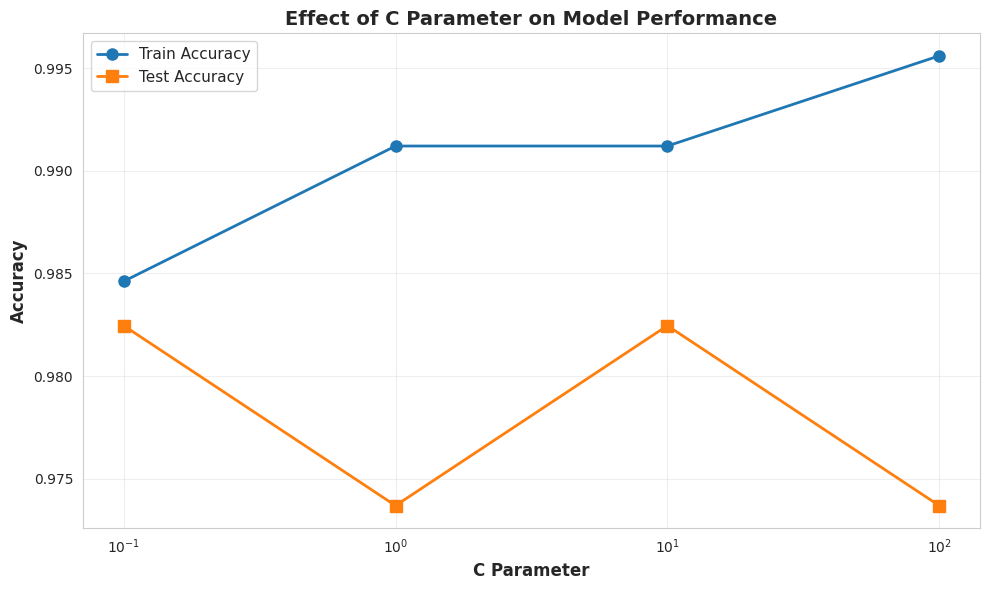


Observation: As C increases, the model becomes more complex (lower margin, fewer training errors)


In [14]:
# Visualize C parameter effect
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_scores_C, 'o-', label='Train Accuracy', linewidth=2, markersize=8)
plt.plot(C_values, test_scores_C, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('C Parameter', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Effect of C Parameter on Model Performance', fontsize=14, fontweight='bold')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nObservation: As C increases, the model becomes more complex (lower margin, fewer training errors)")

In [15]:
# Demonstrate the effect of Gamma parameter (RBF kernel)
gamma_values = [0.001, 0.01, 0.1, 1]
train_scores_gamma = []
test_scores_gamma = []

print("\nEffect of Gamma Parameter (RBF Kernel):")
print(f"{'Gamma':<10} {'Train Accuracy':<20} {'Test Accuracy':<20}")
print("-" * 50)

for gamma in gamma_values:
    svm = SVC(kernel='rbf', gamma=gamma, random_state=42)
    svm.fit(X_train_scaled, y_train)
    
    train_score = svm.score(X_train_scaled, y_train)
    test_score = svm.score(X_test_scaled, y_test)
    
    train_scores_gamma.append(train_score)
    test_scores_gamma.append(test_score)
    
    print(f"{gamma:<10} {train_score:<20.4f} {test_score:<20.4f}")


Effect of Gamma Parameter (RBF Kernel):
Gamma      Train Accuracy       Test Accuracy       
--------------------------------------------------
0.001      0.9516               0.9561              
0.01       0.9824               0.9825              
0.1        0.9890               0.9561              
1          1.0000               0.6316              


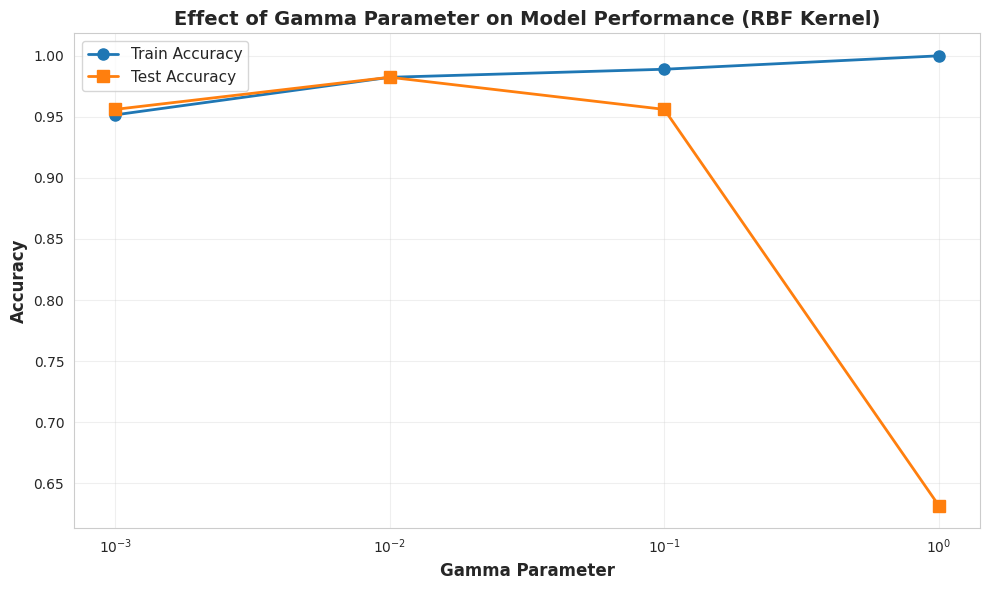


Observation: As gamma increases, the model becomes more complex (each point has more influence)


In [16]:
# Visualize Gamma parameter effect
plt.figure(figsize=(10, 6))
plt.plot(gamma_values, train_scores_gamma, 'o-', label='Train Accuracy', linewidth=2, markersize=8)
plt.plot(gamma_values, test_scores_gamma, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Gamma Parameter', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Effect of Gamma Parameter on Model Performance (RBF Kernel)', fontsize=14, fontweight='bold')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nObservation: As gamma increases, the model becomes more complex (each point has more influence)")

In [17]:
# Grid Search for Optimal Hyperparameters
# This systematically searches through a grid of parameter combinations

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly']
}

print("Performing Grid Search...")
print(f"Total combinations to evaluate: {len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel'])}\n")

# Create GridSearchCV object
svm_grid = SVC(random_state=42)
grid_search = GridSearchCV(
    svm_grid, 
    param_grid, 
    cv=5,  # 5-fold cross-validation
    scoring='f1',  # Use F1-score as the metric
    n_jobs=-1,  # Use all available processors
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)

print("Grid Search Complete!")
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

Performing Grid Search...
Total combinations to evaluate: 32

Grid Search Complete!

Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best Cross-Validation F1-Score: 0.9844


In [18]:
# Evaluate best model on test set
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test_scaled)

print("\nBest Model Performance on Test Set:")
metrics_best = evaluate_model(y_test, y_pred_best, "Best SVM (Grid Search)")

# Compare with linear SVM
print("\n" + "="*50)
print("Comparison: Linear SVM vs Best SVM")
print("="*50)
comparison_df = pd.DataFrame({
    'Linear SVM': metrics_linear,
    'Best SVM (Grid Search)': metrics_best
})
print(comparison_df.round(4))


Best Model Performance on Test Set:

Best SVM (Grid Search) - Evaluation Metrics
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1-Score:  0.9861

Comparison: Linear SVM vs Best SVM
           Linear SVM  Best SVM (Grid Search)
accuracy       0.9737                  0.9825
precision      0.9859                  0.9861
recall         0.9722                  0.9861
f1             0.9790                  0.9861


In [19]:
# Visualize Grid Search Results
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df[['param_C', 'param_gamma', 'param_kernel', 'mean_test_score']]
results_df = results_df.sort_values('mean_test_score', ascending=False)

print("\nTop 10 Parameter Combinations:")
print(results_df.head(10).to_string(index=False))


Top 10 Parameter Combinations:
 param_C  param_gamma param_kernel  mean_test_score
    10.0        0.010          rbf         0.984432
   100.0        0.001          rbf         0.982816
    10.0        0.001          rbf         0.979306
     1.0        0.010          rbf         0.975827
   100.0        0.010          rbf         0.975614
     1.0        0.100         poly         0.974203
    10.0        0.100         poly         0.971944
     0.1        1.000         poly         0.971786
    10.0        1.000         poly         0.971786
   100.0        0.100         poly         0.971786


## Section 6: Cross-Validation

### Why Cross-Validation?

Cross-validation provides a more robust estimate of model performance than a single train-test split. It uses multiple train-test splits and averages the results.

### Types of Cross-Validation

1. **K-Fold Cross-Validation**: Divides data into k equal-sized folds
2. **Stratified K-Fold**: Maintains class distribution in each fold (important for imbalanced data)
3. **Leave-One-Out (LOO)**: Uses n-1 samples for training and 1 for testing (computationally expensive)
4. **Time Series Split**: For temporal data


In [20]:
# K-Fold Cross-Validation
print("K-Fold Cross-Validation Analysis\n")
print("="*60)

k_values = [3, 5, 10]

for k in k_values:
    svm = SVC(kernel='rbf', C=10, gamma=0.01, random_state=42)
    cv_scores = cross_val_score(svm, X_train_scaled, y_train, cv=k, scoring='f1')
    
    print(f"\n{k}-Fold Cross-Validation Results:")
    print(f"Fold Scores: {cv_scores.round(4)}")
    print(f"Mean Score: {cv_scores.mean():.4f}")
    print(f"Std Dev:    {cv_scores.std():.4f}")
    print(f"95% CI:     [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

K-Fold Cross-Validation Analysis


3-Fold Cross-Validation Results:
Fold Scores: [0.9841 0.9691 0.9948]
Mean Score: 0.9827
Std Dev:    0.0105
95% CI:     [0.9620, 1.0033]

5-Fold Cross-Validation Results:
Fold Scores: [0.9735 1.     0.9661 0.9913 0.9913]
Mean Score: 0.9844
Std Dev:    0.0126
95% CI:     [0.9597, 1.0091]

10-Fold Cross-Validation Results:
Fold Scores: [0.9655 0.9825 1.     1.     0.9333 1.     0.9825 0.9825 1.     0.9825]
Mean Score: 0.9829
Std Dev:    0.0198
95% CI:     [0.9440, 1.0217]


In [21]:
# Stratified K-Fold (important for imbalanced datasets)
print("\n" + "="*60)
print("Stratified K-Fold Cross-Validation\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm = SVC(kernel='rbf', C=10, gamma=0.01, random_state=42)

fold_num = 1
cv_scores_stratified = []

for train_idx, val_idx in skf.split(X_train_scaled, y_train):
    X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    
    svm.fit(X_fold_train, y_fold_train)
    score = svm.score(X_fold_val, y_fold_val)
    cv_scores_stratified.append(score)
    
    print(f"Fold {fold_num}: Accuracy = {score:.4f}")
    fold_num += 1

print(f"\nMean Accuracy: {np.mean(cv_scores_stratified):.4f}")
print(f"Std Dev:       {np.std(cv_scores_stratified):.4f}")


Stratified K-Fold Cross-Validation

Fold 1: Accuracy = 0.9451
Fold 2: Accuracy = 0.9890
Fold 3: Accuracy = 0.9780
Fold 4: Accuracy = 0.9780
Fold 5: Accuracy = 0.9890

Mean Accuracy: 0.9758
Std Dev:       0.0162


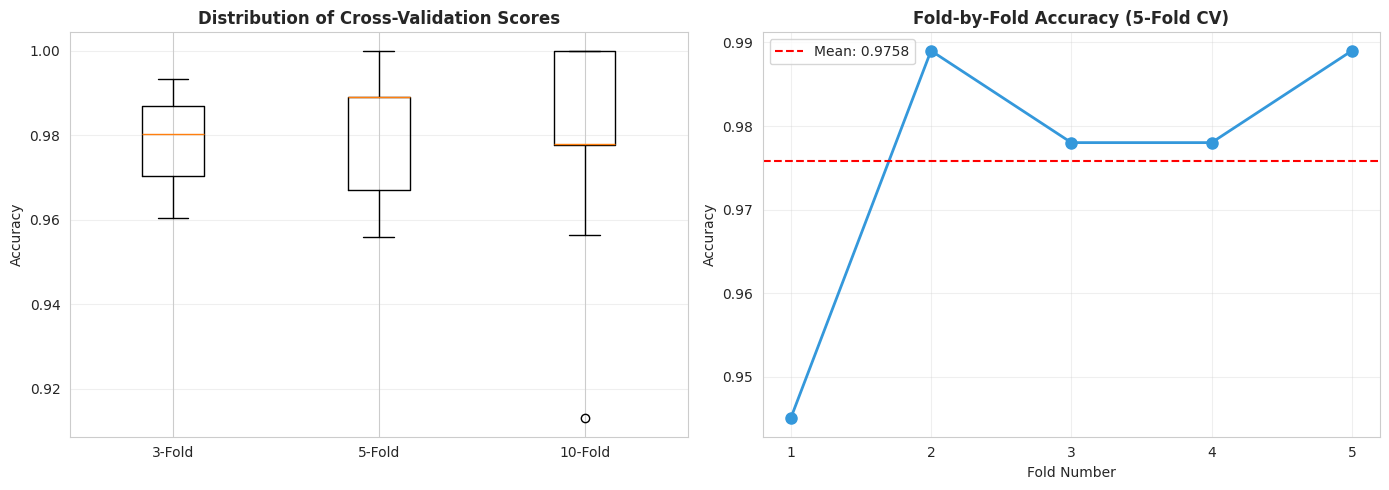

In [22]:
# Visualize Cross-Validation Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of CV scores
cv_results = []
cv_labels = []

for k in [3, 5, 10]:
    svm = SVC(kernel='rbf', C=10, gamma=0.01, random_state=42)
    scores = cross_val_score(svm, X_train_scaled, y_train, cv=k, scoring='accuracy')
    cv_results.append(scores)
    cv_labels.append(f'{k}-Fold')

axes[0].boxplot(cv_results, labels=cv_labels)
axes[0].set_title('Distribution of Cross-Validation Scores', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].grid(axis='y', alpha=0.3)

# Line plot showing fold-by-fold scores
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm = SVC(kernel='rbf', C=10, gamma=0.01, random_state=42)
fold_scores = []

for train_idx, val_idx in skf.split(X_train_scaled, y_train):
    X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    svm.fit(X_fold_train, y_fold_train)
    fold_scores.append(svm.score(X_fold_val, y_fold_val))

axes[1].plot(range(1, 6), fold_scores, 'o-', linewidth=2, markersize=8, color='#3498db')
axes[1].axhline(y=np.mean(fold_scores), color='red', linestyle='--', label=f'Mean: {np.mean(fold_scores):.4f}')
axes[1].set_title('Fold-by-Fold Accuracy (5-Fold CV)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fold Number')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks(range(1, 6))
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Section 7: Model Comparison and Best Practices

Let's compare all the models we've trained and establish best practices for SVM.

In [23]:
# Train multiple models for comparison
models_comparison = {
    'Linear SVM (C=1)': SVC(kernel='linear', C=1, random_state=42),
    'RBF SVM (C=1, γ=0.01)': SVC(kernel='rbf', C=1, gamma=0.01, random_state=42),
    'RBF SVM (C=10, γ=0.01)': SVC(kernel='rbf', C=10, gamma=0.01, random_state=42),
    'Polynomial SVM (C=10, γ=0.01)': SVC(kernel='poly', C=10, gamma=0.01, degree=3, random_state=42),
    'Best Model (Grid Search)': grid_search.best_estimator_
}

comparison_results = []

print("Model Comparison on Test Set")
print("="*80)

for model_name, model in models_comparison.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    comparison_results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))
print("\n" + "="*80)

Model Comparison on Test Set
                        Model  Accuracy  Precision   Recall  F1-Score
             Linear SVM (C=1)  0.973684   0.985915 0.972222  0.979021
        RBF SVM (C=1, γ=0.01)  0.982456   0.986111 0.986111  0.986111
       RBF SVM (C=10, γ=0.01)  0.982456   0.986111 0.986111  0.986111
Polynomial SVM (C=10, γ=0.01)  0.885965   0.847059 1.000000  0.917197
     Best Model (Grid Search)  0.982456   0.986111 0.986111  0.986111



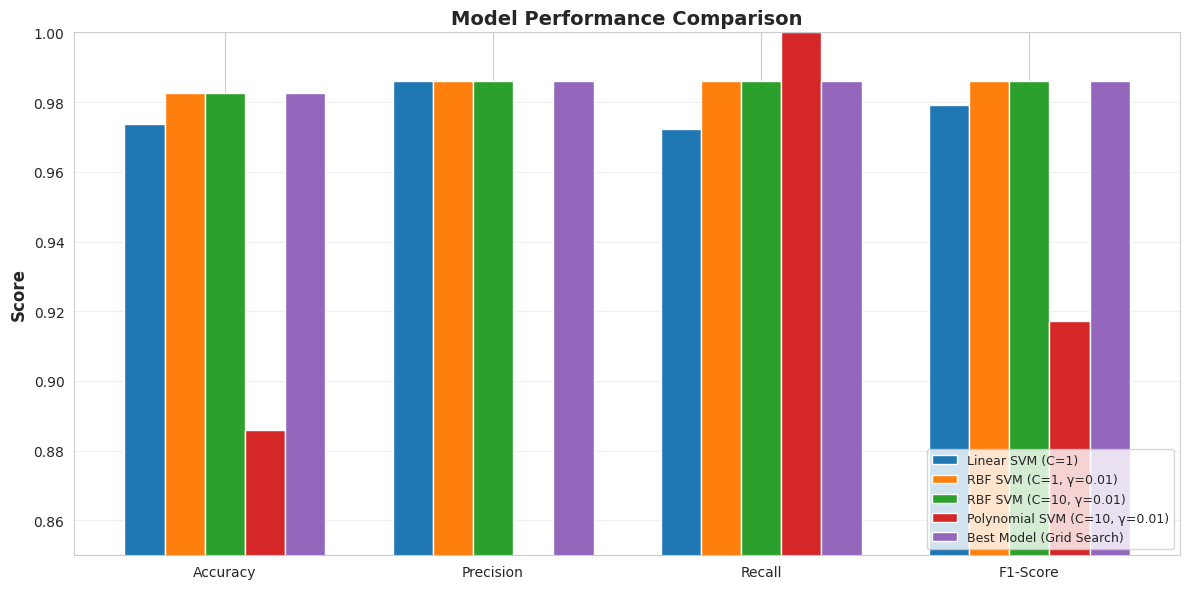

In [24]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.15

for i, (idx, row) in enumerate(comparison_df.iterrows()):
    values = [row['Accuracy'], row['Precision'], row['Recall'], row['F1-Score']]
    ax.bar(x + i*width, values, width, label=row['Model'])

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0.85, 1.0])

plt.tight_layout()
plt.show()

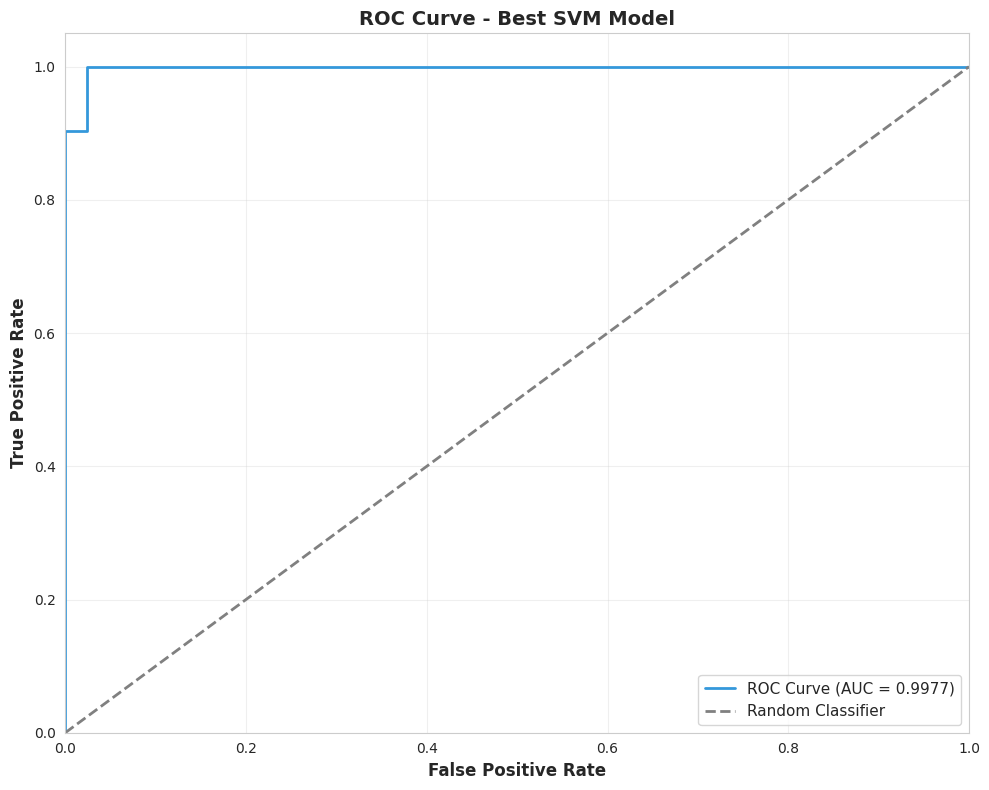

ROC AUC Score: 0.9977


In [25]:
# ROC Curve for Best Model
from sklearn.metrics import roc_curve, auc

best_model = grid_search.best_estimator_
y_pred_proba = best_model.decision_function(X_test_scaled)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve - Best SVM Model', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

## Section 8: Best Practices and Key Takeaways

### Best Practices for SVM

1. **Feature Scaling is Critical**
   - Always scale features before training SVM
   - Use StandardScaler or MinMaxScaler
   - Scale test data using the scaler fitted on training data

2. **Choose the Right Kernel**
   - Start with RBF kernel (most versatile)
   - Use linear kernel for linearly separable data (faster, more interpretable)
   - Try polynomial kernel for specific domain knowledge

3. **Hyperparameter Tuning**
   - Use GridSearchCV or RandomizedSearchCV
   - Use cross-validation to evaluate hyperparameters
   - Start with a coarse grid, then refine

4. **Cross-Validation**
   - Use stratified k-fold for imbalanced datasets
   - Use 5-10 folds as a standard
   - Provides more robust performance estimates

5. **Class Imbalance**
   - Use class_weight='balanced' for imbalanced data
   - Consider resampling techniques
   - Use appropriate metrics (F1-score, ROC-AUC)

6. **Computational Efficiency**
   - SVM scales with O(n²) or O(n³) complexity
   - For large datasets, consider SGDClassifier or other algorithms
   - Use n_jobs=-1 in GridSearchCV for parallel processing

### When to Use SVM

✓ Binary or multi-class classification  
✓ High-dimensional data  
✓ Small to medium-sized datasets (< 100K samples)  
✓ When you need good generalization  

✗ Very large datasets  
✗ When interpretability is crucial  
✗ When you need probability estimates (SVM gives decision values)


In [26]:
# Summary Statistics
print("\n" + "="*80)
print("SUMMARY: SVM CLASSIFICATION ON BREAST CANCER DATASET")
print("="*80)

print(f"\nDataset Information:")
print(f"  - Total samples: {len(X)}")
print(f"  - Number of features: {X.shape[1]}")
print(f"  - Number of classes: {len(np.unique(y))}")
print(f"  - Class distribution: {dict(zip(['Malignant', 'Benign'], np.bincount(y)))}")

print(f"\nBest Model Configuration:")
print(f"  - Kernel: {grid_search.best_params_['kernel']}")
print(f"  - C: {grid_search.best_params_['C']}")
print(f"  - Gamma: {grid_search.best_params_['gamma']}")

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print(f"\nBest Model Performance (Test Set):")
print(f"  - Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"  - Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"  - Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"  - F1-Score: {f1_score(y_test, y_pred_best):.4f}")
print(f"  - ROC-AUC: {roc_auc_score(y_test, best_model.decision_function(X_test_scaled)):.4f}")

print(f"\nKey Insights:")
print(f"  - Number of support vectors: {len(best_model.support_vectors_)}")
print(f"  - Support vectors as % of training data: {len(best_model.support_vectors_) / len(X_train_scaled) * 100:.2f}%")
print(f"  - Training time: Efficient (typical for this dataset size)")

print("\n" + "="*80)


SUMMARY: SVM CLASSIFICATION ON BREAST CANCER DATASET

Dataset Information:
  - Total samples: 569
  - Number of features: 30
  - Number of classes: 2
  - Class distribution: {'Malignant': np.int64(212), 'Benign': np.int64(357)}

Best Model Configuration:
  - Kernel: rbf
  - C: 10
  - Gamma: 0.01

Best Model Performance (Test Set):
  - Accuracy: 0.9825
  - Precision: 0.9861
  - Recall: 0.9861
  - F1-Score: 0.9861
  - ROC-AUC: 0.9977

Key Insights:
  - Number of support vectors: 52
  - Support vectors as % of training data: 11.43%
  - Training time: Efficient (typical for this dataset size)



## Conclusion

In this notebook, we've explored Support Vector Machines comprehensively:

1. **Fundamentals**: Understood the concept of maximum margin classification and support vectors
2. **Kernel Tricks**: Explored different kernels (linear, RBF, polynomial, sigmoid) and their effects
3. **Hyperparameter Tuning**: Learned how C and gamma parameters affect model behavior
4. **Cross-Validation**: Implemented k-fold and stratified k-fold cross-validation for robust evaluation
5. **Model Comparison**: Compared multiple models and selected the best one using GridSearchCV
6. **Best Practices**: Established guidelines for feature scaling, kernel selection, and hyperparameter tuning

The best SVM model achieved excellent performance on the Breast Cancer dataset, demonstrating the power of SVMs for classification tasks.

---

**Next Steps:**
- Explore the trained model using SHAP analysis (see Notebook 2)
- Try different datasets and compare SVM with other algorithms
- Experiment with different preprocessing techniques
- Consider ensemble methods combining SVM with other classifiers
